In [69]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [70]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [71]:
# Load EuroSAT Dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [72]:
# Define Encoder for 64X64 RGB

class Encoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 256, 4, 2, 1)

        self.fc_mu = nn.Linear(256*4*4, latent_dimension)
        self.fu_logVar = nn.Linear(256*4*4, latent_dimension)

    def forward(self, input):
        input = F.relu(self.conv1(input))
        input = F.relu(self.conv2(input))
        input = F.relu(self.conv3(input))
        input = F.relu(self.conv4(input))

        input = input.view(input.size(0), -1)

        mu = self.fc_mu(input)
        log_var = self.fu_logVar(input)

        return mu, log_var


In [73]:
# Reparameterization (Sampling)

def reparameterized(mu, log_var):
        std = torch.exp(0.5 * log_var) # compute standared deviation
        eps = torch.randn_like(std) # eps is randomness 
        return mu + std * eps # sampling

In [74]:
# Decoder

class Decoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.fc = nn.Linear(latent_dimension, 256*4*4)
        self.deconv1 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv4 = nn.ConvTranspose2d(32, 3, 4, 2, 1)

    def forward(self, z):
        de_input = self.fc(z)
        de_input = de_input.view(z.size(0), 256, 4, 4)

        de_input = F.relu(self.deconv1(de_input))
        de_input = F.relu(self.deconv2(de_input))
        de_input = F.relu(self.deconv3(de_input))
        de_input = torch.sigmoid(self.deconv4(de_input))

        return de_input;

In [75]:
# VAE Model

class VAE(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.encoder = Encoder(latent_dimension)
        self.decoder = Decoder(latent_dimension)

    def forward(self, input):
        mu, log_var = self.encoder(input)
        z = reparameterized(mu, log_var)
        input_recon = self.decoder(z)

        return input_recon, mu, log_var

In [76]:
# Loss function
def vae_loss(recon_x, x, mu, log_var):

    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    kl = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    )
    beta = 0.0005
    loss = recon_loss + beta * kl
    return loss

In [77]:
# Initialize the model

latent_dimension = 64
model = VAE(latent_dimension).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

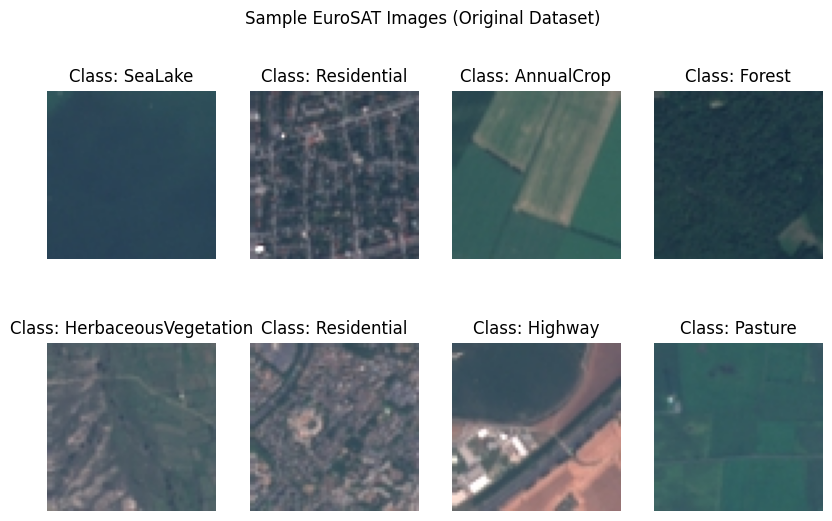

In [78]:
# Generate the Raw Images pre-decoding using VAE model
images, labels = next(iter(dataloader))

plt.figure(figsize=(10,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Class: {dataset.classes[labels[i]]}")
    plt.axis("off")

plt.suptitle("Sample EuroSAT Images (Original Dataset)")
plt.show()

In [79]:
# Training Loop

epochs = 20
history_of_loss = []

for epoch in range(epochs):
    total_loss = 0
    
    for images, _ in dataloader:

        images = images.to(device)
        recon, mu, log_var = model(images)
        loss = vae_loss(recon, images, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader.dataset)
    history_of_loss.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 7716.5983
Epoch 2, Loss: 7611.5829
Epoch 3, Loss: 7592.2874
Epoch 4, Loss: 7571.0273
Epoch 5, Loss: 7564.6930
Epoch 6, Loss: 7557.5551
Epoch 7, Loss: 7555.1265
Epoch 8, Loss: 7552.4028
Epoch 9, Loss: 7550.7359
Epoch 10, Loss: 7547.9617
Epoch 11, Loss: 7545.3532
Epoch 12, Loss: 7544.8974
Epoch 13, Loss: 7542.9646
Epoch 14, Loss: 7542.4825
Epoch 15, Loss: 7540.5474
Epoch 16, Loss: 7540.2863
Epoch 17, Loss: 7538.7395
Epoch 18, Loss: 7539.2863
Epoch 19, Loss: 7537.5021
Epoch 20, Loss: 7536.8157


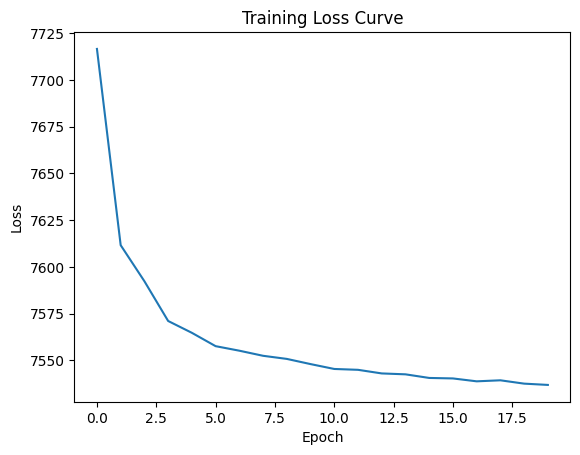

In [80]:
# Plot Training Loss
plt.plot(history_of_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

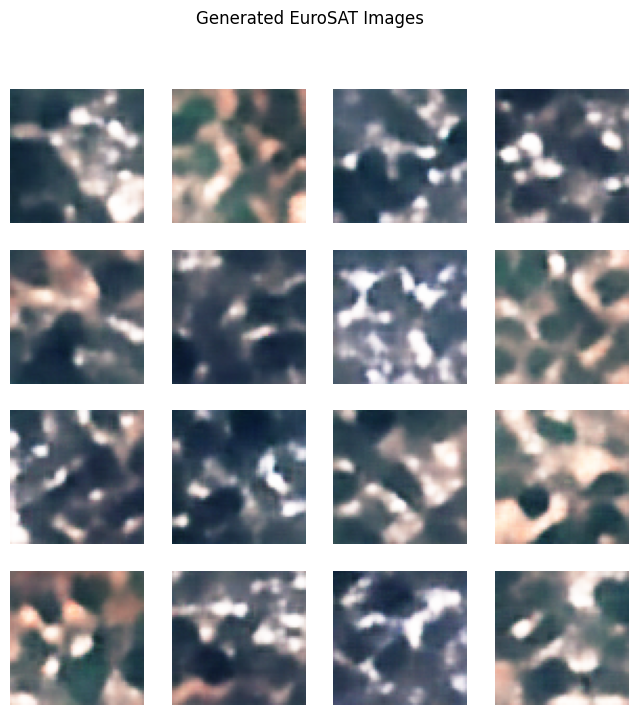

In [81]:
# Generate new Satelite Images

model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dimension).to(device)
    reGenerated = model.decoder(z).cpu()

rows = 4
cols = 4

plt.figure(figsize=(8,8))

for i in range(rows * cols):
    plt.subplot(rows, cols, i+1)
    plt.imshow(reGenerated[i].permute(1,2,0).clamp(0,1))
    plt.axis("off")

plt.suptitle("Generated EuroSAT Images")
plt.show()

### Task 3: Latent Space Interpolation

To test if the Variational Autoencoder has learned meaningful and continuous latent representation we do interpolation at the latent space.

EuroSAT data consists of two images which are initially coded into the latent vectors. Then, line linear interpolation is done on these two vectors to make intermediate latent vectors. The decoder is applied to each of the interpolated vectors and creates an image.

The decoded images would display a visual transition between the two original image with smooth transition, should the VAE have learned a structured latent space.


In [82]:
# Select two images

model.eval()

images, labels = next(iter(dataloader))
images = images.to(device)

# pick two images
image_1 = images[0].unsqueeze(0)
image_2 = images[1].unsqueeze(0)

print("Image A class:", dataset.classes[labels[0]])
print("Image B class:", dataset.classes[labels[1]])

Image A class: SeaLake
Image B class: SeaLake


In [83]:
# Encode both images 
# Converting images -> latent vectors

with torch.no_grad():

    mu1, log_var1 = model.encoder(image_1)
    z1 = reparameterized(mu1, log_var1)

    mu2, log_var2 = model.encoder(image_2)
    z2 = reparameterized(mu2, log_var2)

In [84]:
# Create Interpolation

steps = 10
alphas = torch.linspace(0, 1, steps).to(device)

interpolated_images = []

with torch.no_grad():
    for alpha in alphas:

        z = (1 - alpha) * z1 + alpha * z2

        img = model.decoder(z)

        interpolated_images.append(img.cpu())

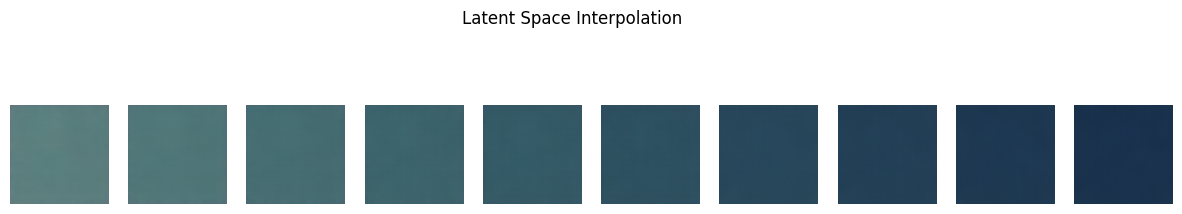

In [85]:
# Visualize the Transition

plt.figure(figsize=(15, 3))

for i in range(steps):
    plt.subplot(1, steps, i+1)

    image = interpolated_images[i][0].permute(1,2,0)

    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Latent Space Interpolation")
plt.show()

### Task 4: Concept Manipulation in Latent Space

In order to investigate whether Variational Autoencoder has acquired meaningful semantic directions in the latent space, we use latent vector arithmetic.

The concept is to calculate a latent direction that depicts the concept of paving. This direction is calculated by taking away the average latent representation of forest images and then the average latent representation of highway images.

The resultant vector is known as the Paving Direction. With this inserted into the latent representation of one scene (say a river), we can see how the scene varies upon introduction of the concept of paving.

In case the latent space represents meaningful features, a decoded image is supposed to have structural variations with respect to roads or paved surfaces without altering the original scene structure.


In [86]:
# Select two images

forest_images = []
highway_images = []

for img, label in dataset:
    
    if dataset.classes[label] == "Forest":
        forest_images.append(img)
        
    if dataset.classes[label] == "Highway":
        highway_images.append(img)

    if len(forest_images) >= 32 and len(highway_images) >= 32:
        break

forest_batch = torch.stack(forest_images).to(device)
highway_batch = torch.stack(highway_images).to(device)


In [87]:
# Encode both images 
# Converting images -> latent vectors

with torch.no_grad():

    mu_forest, logvar_forest = model.encoder(forest_batch)
    z_forest = reparameterized(mu_forest, logvar_forest)

    mu_highway, logvar_highway = model.encoder(highway_batch)
    z_highway = reparameterized(mu_highway, logvar_highway)

In [88]:
# Compute Average Latent Vectors

forest_mean = z_forest.mean(dim=0)
highway_mean = z_highway.mean(dim=0)

In [89]:
# Compute the "Paving Direction"

paving_direction = highway_mean - forest_mean

In [90]:
# Apply Direction to a River Image

river_img = None

for img, label in dataset:
    if dataset.classes[label] == "River":
        river_img = img.unsqueeze(0).to(device)
        break

# Encode

with torch.no_grad():
    
    mu_river, logvar_river = model.encoder(river_img)
    z_river = reparameterized(mu_river, logvar_river)

# Modify the River Latent Vector
z_modified = z_river + paving_direction

# Decode
generated = model.decoder(z_modified)

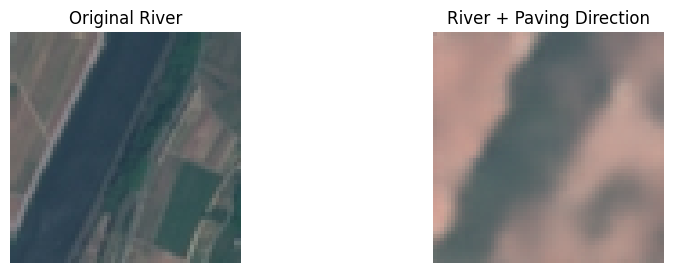

In [91]:
# Visualize the Results

plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.imshow(river_img[0].detach().cpu().permute(1,2,0))
plt.title("Original River")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(generated[0].detach().cpu().permute(1,2,0))
plt.title("River + Paving Direction")
plt.axis("off")

plt.show()

### Analysis

Latent arithmetic experiment shows that the VAE latent space represents significant semantic directions. The calculated "Paving Direction" is the conversion of forest textures to highways.

When this vector is superimposed on the latent representation of a river scene the resulting image indicates surface texture and maintains the original spatial structure of the river. This implies that the model will have acquired feature-level representations that can be manipulated with the help of the latent space in terms of vector operations.
